<a href="https://colab.research.google.com/github/brenda96011/IA-2026-2/blob/main/tema4/21_UNAM_AI_Actividad_Laboratorio_4_2_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 4.2 Clase}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Rodríguez Jiménez Brenda \\[6pt]
\textbf{Fecha de realización:} & 28/04/2026
\end{array}

</center>

In [11]:
import numpy as np

# Regresión lineal y logaritmica

In [12]:
class RegresionLineal:
    """
    Modelo de regresión lineal simple.
    """

    def __init__(self, alpha: float = 0.01, iteraciones: int = 1000) -> None:
        """
        Inicializamos el modelo con la tasa de aprendizaje
        y el número de iteraciones.
        """
        self.alpha = alpha
        self.iteraciones = iteraciones
        self.w = None
        self.b = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrenamiento del modelo.
        """
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        for _ in range(self.iteraciones):
            # Predicción lineal
            y_pred = np.dot(X, self.w) + self.b

            # Cálculo de gradientes
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Actualización de parámetros
            self.w -= self.alpha * dw
            self.b -= self.alpha * db

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice valores con base en la entrada.
        """
        return np.dot(X, self.w) + self.b

In [13]:
class RegresionLogistica:
    def __init__(self, alpha: float = 0.01, iteraciones: int = 1000) -> None:
        """
        Inicializa el modelo de regresión logística con
        tasa de aprendizaje y número de iteraciones.
        """
        self.alpha = alpha
        self.iteraciones = iteraciones

        self.w = None
        self.b = None

    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        """
        Aplica la función sigmoide a la entrada para mapear
        valores a probabilidades entre 0 y 1.
        """
        return 1 / (1 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrena el modelo.
        """
        n_samples, n_features = X.shape
        #1. Inicializar theta (ceros) y m_features asegurda que
        #tengamos un peso para cada variable
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.iteraciones):
            #2a. Calcular producto lineal es la base de la regresión
            modelo_lineal = np.dot(X, self.w) + self.b
            # aplicar Sigmoide, probabilidad entre 0 y 1
            y_pred = self._sigmoid(modelo_lineal)
            # Calcula el error con y_pred -y
            # calcular el gradiante dw y db
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            #Actualizar parámetros
            self.w -= self.alpha * dw
            self.b -= self.alpha * db

    def predict(self, X: np.ndarray) -> list[int]:
        """
        Predice las clases para los datos de entrada con un umbral de 0.5.
        """
        modelo_lineal = np.dot(X, self.w) + self.b
        y_pred = self._sigmoid(modelo_lineal)
        #Retorna el umbral de decisión (threshold)
        #Por defecto usamos 0.5:
        # Si la probabilidad es > 0.5 -> Clase 1 (Aprobado).
        # Si la probabilidad es <= 0.5 -> Clase 0 (Reprobado).
        return [1 if i > 0.5 else 0 for i in y_pred]

Aplicandolo:

Resultado para 5.5 horas: Aprobado


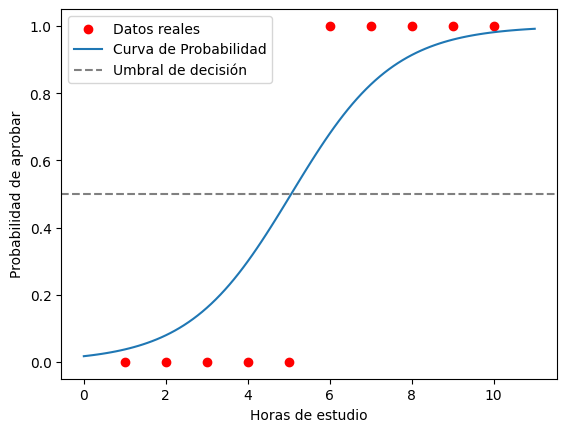

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE DATOS (Simulando una clase real) ---
# Horas de estudio de 10 alumnos
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
# 0 = Reprobado, 1 = Aprobado
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# --- 2. EL MODELO (Usando la lógica que desarrollamos antes) ---
modelo = RegresionLogistica(alpha=0.1, iteraciones=500)
modelo.fit(X, y)

# --- 3. PREDICCIÓN APLICADA ---
# ¿Qué pasa con un alumno que estudia 5.5 horas?
horas_nuevas = np.array([[5.5]])
prediccion = modelo.predict(horas_nuevas)

resultado = "Aprobado" if prediccion[0] == 1 else "Reprobado"
print(f"Resultado para 5.5 horas: {resultado}")

# --- 4. VISUALIZACIÓN (Crucial en experimentación) ---
plt.scatter(X, y, color='red', label='Datos reales')
# Generamos puntos para ver la curva sigmoide
X_curva = np.linspace(0, 11, 100).reshape(-1, 1)
z = np.dot(X_curva, modelo.w) + modelo.b
probabilidades = 1 / (1 + np.exp(-z))

plt.plot(X_curva, probabilidades, label='Curva de Probabilidad')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Umbral de decisión')
plt.xlabel("Horas de estudio")
plt.ylabel("Probabilidad de aprobar")
plt.legend()
plt.show()

# SVM

In [15]:
import numpy as np
from sklearn.svm import SVC # La versión profesional

class SVM_Manual:
    def __init__(self, learning_rate: float = 0.001,
                 lambda_param: float = 0.01, n_iters: int = 1000) -> None:
        """
        Inicializa el modelo SVM con tasa de aprendizaje,
        parámetro de regularización y número de iteraciones.
        """
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrena el modelo SVM.
        """
        # Convertir etiquetas a [-1, 1] si vienen como [0, 1]
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Condición de la pérdida Hinge
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w
                                         - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice las clases para los datos de entrada.
        """
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

Para probar la implementación manual de SVM, se necesita generar datos sintéticos que sepamos que son "separables" para verificar si el algoritmo encuentra los pesos correctos.

Pesos finales (w): [0.58977016 0.17946483]
Sesgo final (b): -0.1520000000000001


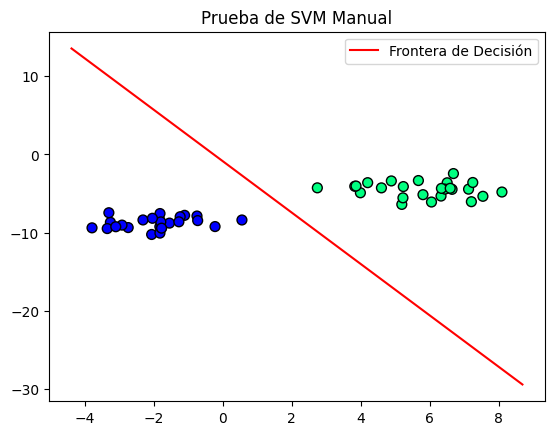

In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Generamos datos de prueba (2 grupos de puntos)
# Usamos etiquetas -1 y 1 porque así lo definimos en el algoritmo manual
X, y = make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40)
y = np.where(y == 0, -1, 1)

# 2. Instanciamos y entrenamos el modelo manual
modelo_svm = SVM_Manual(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
modelo_svm.fit(X, y)

print(f"Pesos finales (w): {modelo_svm.w}")
print(f"Sesgo final (b): {modelo_svm.b}")

# 3. Función para visualizar el resultado
def visualizar_svm(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=50, edgecolors='k')
    ax = plt.gca()
    xlim = ax.get_xlim()

    # Calculamos la línea de decisión: w1*x1 + w2*x2 - b = 0
    # Despejando x2: x2 = (-w1*x1 + b) / w2
    x1 = np.linspace(xlim[0], xlim[1], 100)
    x2 = (model.b - model.w[0] * x1) / model.w[1]

    plt.plot(x1, x2, 'r-', label="Frontera de Decisión")
    plt.title("Prueba de SVM Manual")
    plt.legend()
    plt.show()

visualizar_svm(X, y, modelo_svm)

Análisis de los Resultados
 1. Separación Lineal: La línea roja (tu frontera de decisión) ha logrado separar perfectamente el grupo azul del grupo verde. Esto indica que el hiperplano encontrado es válido.

 2. Los Pesos ($w$): Tus pesos finales $[0.5897, 0.1794]$ no son cero, lo que significa que el algoritmo actualizó los parámetros mediante el gradiente de forma efectiva.

 3. El Sesgo ($b$): El valor de $-0.152$ es el que desplaza la línea fuera del origen $(0,0)$ para que pueda quedar justo en medio de las dos "nubes" de puntos.

 4. Optimización del Margen: Nota que la línea no está "pegada" a un grupo, sino que intenta mantener una distancia prudente de ambos. Eso es exactamente lo que busca una SVM: maximizar el margen.

# k-Nearest Neighbors (k-NN)

In [17]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k: int = 3) -> None:
        """
        Inicializa el modelo k-NN con el número de vecinos más cercanos.
        """
        self.k = k

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Almacena los datos de entrenamiento.
        """
        # En k-NN el "entrenamiento" es simplemente almacenar los datos
        # Complejidad en tiempo: O(1)
        self.X_train = X
        self.y_train = y

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice las etiquetas para un conjunto de datos de entrada.
        """
        # Predecimos para cada punto en el conjunto de entrada
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x: np.ndarray) -> int:
        """
        Predice la etiqueta para un punto usando los k vecinos más cercanos.
        """
        # 1. Calcular distancias entre x y todos los puntos en X_train
        # Usamos la norma euclidiana: ||x1 - x2||
        distances = [np.sqrt(np.sum((x - x_train)**2)) for x_train in self.X_train]

        # 2. Obtener los índices de los k vecinos más cercanos
        # np.argsort nos da los índices que ordenarían el arreglo
        k_indices = np.argsort(distances)[:self.k]

        # 3. Extraer las etiquetas de esos k vecinos
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # 4. Votación mayoritaria
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

Puntos clave:

- Vectorización con NumPy: En la línea np.sqrt(np.sum((x - x_train)**2)), estamos aplicando el formalismo matemático de la distancia euclidiana. Se prefiere operaciones vectorizadas sobre ciclos for anidados (eficiencia de memoria y caché).

- argsort vs sort: No nos interesa la distancia en sí para el resultado final, sino el índice del dato original que generó esa distancia, para poder buscar su etiqueta en y_train.

- El rol de Counter: Es la forma más limpia en Python de implementar la "Votación de Pluralidad" que pusimos en el pseudocódigo.

- Escalabilidad: Por cada punto nuevo en X_new, tenemos que recorrer todo X_train. Si el dataset fuera de 1 millón de registros, el tiempo de respuesta (latencia) sería inaceptable para una aplicación real.

# Desafio
Modificar el código para que soporte distancia de Manhattan ($L_1$) o que implementen un esquema de pesos, donde los vecinos más cercanos tengan más influencia en el voto que los que están más lejos.

In [18]:
if __name__ == "__main__":
    # Datos sintéticos: [característica 1, característica 2]
    X_train = np.array([[1, 2], [2, 3], [1.5, 1.8], [7, 8], [8, 9], [7, 6.5]])
    y_train = np.array([0, 0, 0, 1, 1, 1]) # Clase 0 y Clase 1

    clf = KNN(k=3)
    clf.fit(X_train, y_train)

    # Un nuevo punto que queremos clasificar
    X_new = np.array([[4, 5]])
    predicciones = clf.predict(X_new)

    print(f"Predicciones para los nuevos puntos: Clase {predicciones[0]}")

Predicciones para los nuevos puntos: Clase 0


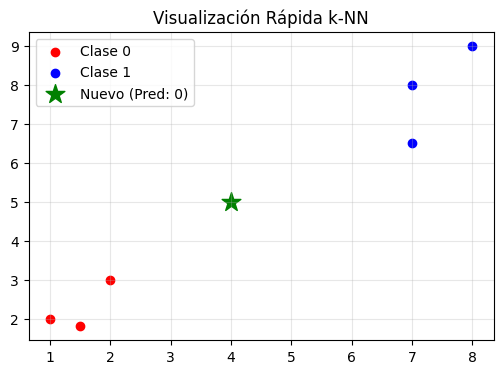

In [19]:
# --- CÓDIGO DE VISUALIZACIÓN RÁPIDA ---
import matplotlib.pyplot as plt

# 1. Datos pequeños (mismo formato de tu fit)
X_train = np.array([[1, 2], [2, 3], [1.5, 1.8], [7, 8], [8, 9], [7, 6.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

# 2. Instanciar y "entrenar" con tu clase
clf = KNN(k=3)
clf.fit(X_train, y_train)

# 3. Punto nuevo a clasificar
X_nuevo = np.array([[4, 5]])
prediccion = clf.predict(X_nuevo)

# 4. Dibujo directo
plt.figure(figsize=(6, 4))

# Dibujamos los puntos de entrenamiento (Clase 0 rojos, Clase 1 azules)
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='red', label='Clase 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='blue', label='Clase 1')

# Dibujamos el punto nuevo como una estrella verde
plt.scatter(X_nuevo[:, 0], X_nuevo[:, 1], c='green', marker='*', s=200,
            label=f'Nuevo (Pred: {prediccion[0]})')

plt.title("Visualización Rápida k-NN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Arbol de Decisión

In [20]:
import numpy as np
from collections import Counter

class Nodo:
    def __init__(self, feature: int | None = None, threshold: float | None = None,
                 left: "Nodo | None" = None, right: "Nodo | None" = None,
                 value: int | None = None) -> None:
        """
        Representa un nodo en el árbol de decisión.
        """
        self.feature = feature     # Índice de la característica usada para dividir
        self.threshold = threshold # Valor de corte
        self.left = left           # Sub-árbol izquierdo
        self.right = right         # Sub-árbol derecho
        self.value = value         # Valor si el nodo es una hoja (la clase)

class ArbolDecision:
    def __init__(self, max_depth: int = 5) -> None:
        """
        Inicializa el árbol de decisión con una profundidad máxima.
        """
        self.max_depth = max_depth
        self.root = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrena el árbol de decisión a partir de los datos de entrada.
        """
        self.root = self._crear_arbol(X, y, depth=0)

    def _crear_arbol(self, X: np.ndarray, y: np.ndarray, depth: int) -> Nodo:
        """
        Construye recursivamente el árbol de decisión.
        """
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Caso base: hoja (todos de la misma clase o profundidad máxima)
        if depth >= self.max_depth or n_labels == 1:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Nodo(value=leaf_value)

        # Encontrar el mejor corte
        best_feat, best_thresh = self._mejor_criterio(X, y, n_features)

        # Crear sub-árboles
        left_idx = X[:, best_feat] <= best_thresh
        right_idx = X[:, best_feat] > best_thresh

        izq = self._crear_arbol(X[left_idx], y[left_idx], depth + 1)
        der = self._crear_arbol(X[right_idx], y[right_idx], depth + 1)

        return Nodo(feature=best_feat, threshold=best_thresh, left=izq, right=der)

    def _mejor_criterio(self, X: np.ndarray, y: np.ndarray,
                        n_features: int) -> tuple[int | None, float | None]:
        """
        Encuentra la mejor característica y umbral para dividir los datos.
        """
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in range(n_features):
            thresholds = np.unique(X[:, feat_idx])
            for threshold in thresholds:
                gain = self._informacion_ganada(X[:, feat_idx], y, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
        return split_idx, split_thresh

    def _informacion_ganada(self, feature_col: np.ndarray, y: np.ndarray,
                            threshold: float) -> float:
        """
        Calcula la ganancia de información para una posible división.
        """
        # Entropía padre
        parent_entropy = self._entropia(y)

        # Crear hijos
        left_idx = feature_col <= threshold
        right_idx = feature_col > threshold

        if len(y[left_idx]) == 0 or len(y[right_idx]) == 0: return 0

        # Entropía hijos ponderada
        n = len(y)
        n_l, n_r = len(y[left_idx]), len(y[right_idx])
        child_entropy = (n_l/n) * self._entropia(y[left_idx]) + (n_r/n) * self._entropia(y[right_idx])

        return parent_entropy - child_entropy

    def _entropia(self, y: np.ndarray) -> float:
        """
        Calcula la entropía de un conjunto de etiquetas.
        """
        proportions = np.bincount(y) / len(y)
        return -np.sum([p * np.log2(p) for p in proportions if p > 0])

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice las etiquetas para un conjunto de datos usando el árbol entrenado.
        """
        return np.array([self._recorrer_arbol(x, self.root) for x in X])

    def _recorrer_arbol(self, x: np.ndarray, nodo: Nodo) -> int:
        """
        Recorre el árbol de decisión para predecir la etiqueta de una muestra.
        """
        if nodo.value is not None: return nodo.value

        if x[nodo.feature] <= nodo.threshold:
            return self._recorrer_arbol(x, nodo.left)
        return self._recorrer_arbol(x, nodo.right)

Puntos clave:

- La clase Nodo: Es fundamental que se entienda que el árbol no es un arreglo, sino una estructura de datos enlazada. Cada nodo o es una "pregunta" (feature y threshold) o es una "respuesta" (value).

- Recursividad: La función de _crear_arbol se llama a sí mismo para construir las ramas. Es una aplicación real y poderosa de lo que ven en sus clases de diseño y análisis de algoritmos.

-La Entropía: El método _entropia usa np.bincount para contar cuántos elementos hay de cada clase, tal cual la fórmula $H(S) = - \sum p_i \log_2(p_i)$.

- Greedy Search (Búsqueda Ávida): Es importante comprender que el algoritmo prueba todos los umbrales posibles para todas las características en cada paso para encontrar el mejor. Esto explica por qué el entrenamiento es $O(n \cdot d \cdot \log n)$.

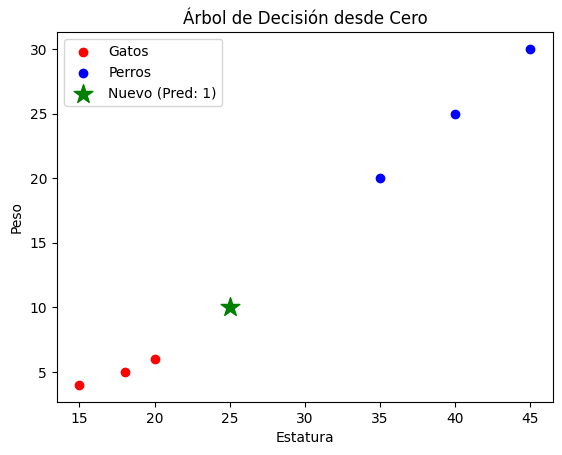

In [21]:
# --- Ejecución y Dibujo Rápido ---
import matplotlib.pyplot as plt

if __name__ == "__main__":
    # Dataset simple: [Estatura, Peso] -> 0: Gato, 1: Perro
    X_train = np.array([[15, 4], [18, 5], [20, 6], [35, 20], [40, 25], [45, 30]])
    y_train = np.array([0, 0, 0, 1, 1, 1])

    clf = ArbolDecision(max_depth=2)
    clf.fit(X_train, y_train)

    # Punto nuevo
    X_test = np.array([[25, 10]])
    pred = clf.predict(X_test)

    # Gráfica
    plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='red', label='Gatos')
    plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='blue', label='Perros')
    plt.scatter(X_test[:, 0], X_test[:, 1], c='green', marker='*', s=200, label=f'Nuevo (Pred: {pred[0]})')
    plt.xlabel("Estatura")
    plt.ylabel("Peso")
    plt.legend()
    plt.title("Árbol de Decisión desde Cero")
    plt.show()

## Con nodos

Árbol entrenado y visualización generada.

Predicción para [25 10]: Perro
Ruta de nodos tomada: [0, 2]


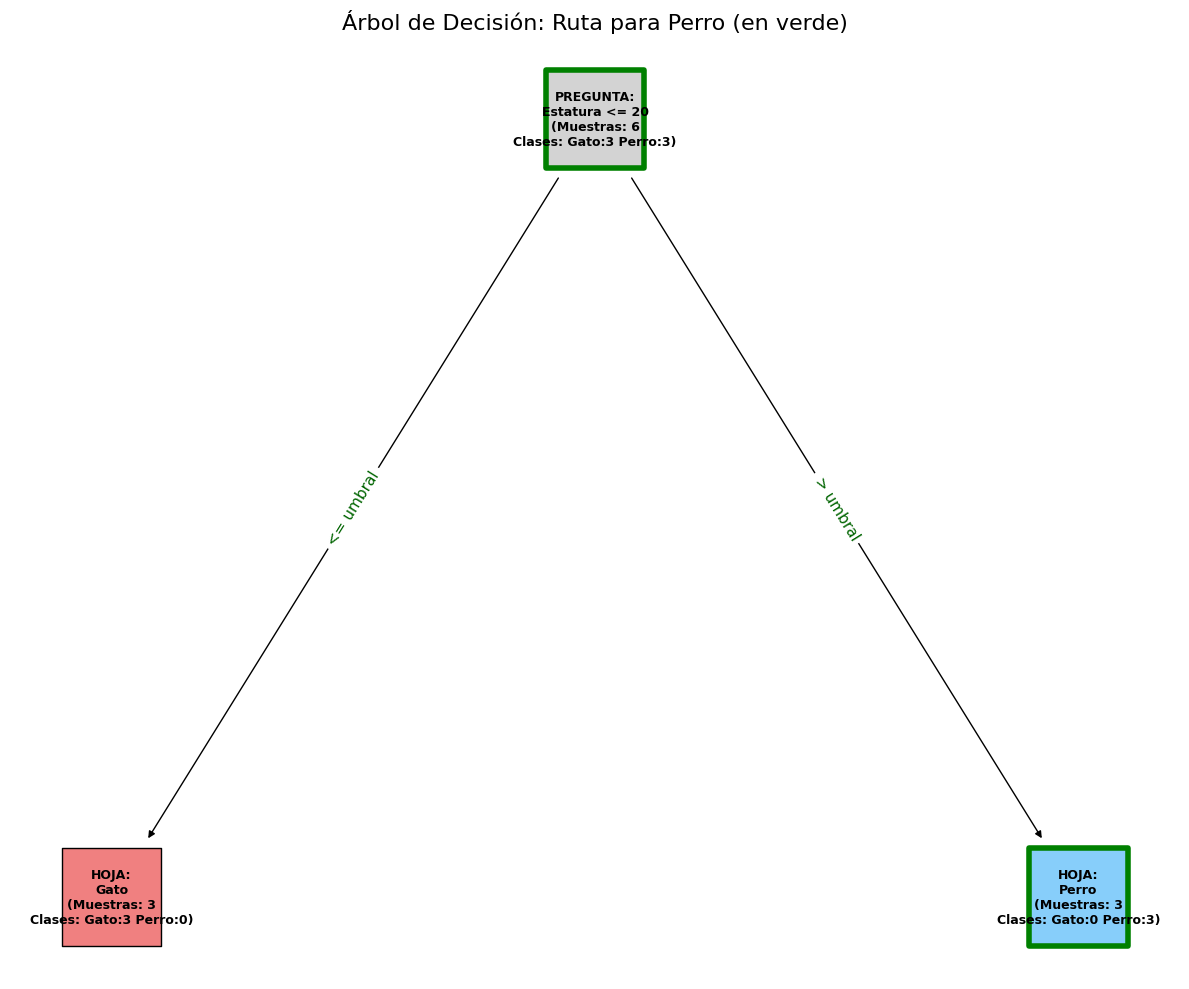

In [22]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx
import pydot
from networkx.drawing.nx_pydot import graphviz_layout

# ============================================================
# 1. Definición de Clases con Estado de Datos
# ============================================================

class Nodo:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None, X_indices=None, class_counts=None):
        self.feature = feature     # Índice de la característica de corte
        self.threshold = threshold # Valor de corte
        self.left = left           # Sub-árbol izquierdo
        self.right = right         # Sub-árbol derecho
        self.value = value         # Clase final (si es hoja)
        self.X_indices = X_indices # Índices de X_train en este nodo
        self.class_counts = class_counts # Conteo de clases en este nodo (ej: {0: 3, 1: 0})

class ArbolDecisionVisual:
    def __init__(self, max_depth=5, feature_names=None, class_names=None):
        self.max_depth = max_depth
        self.root = None
        self.feature_names = feature_names # Ej: ['Estatura', 'Peso']
        self.class_names = class_names     # Ej: ['Gato', 'Perro']
        self.graph = nx.DiGraph()          # Grafo de NetworkX
        self.node_labels = {}              # Etiquetas de texto para los nodos
        self.node_colors = {}              # Colores para los nodos

    # ============================================================
    # 2. Métodos de Entrenamiento (fit) con Generación de Visualización
    # ============================================================

    def fit(self, X, y):
        # Guardamos las referencias a los datos completos para la visualización
        self.X_train = X
        self.y_train = y
        indices_iniciales = np.arange(X.shape[0])
        self.root = self._crear_arbol_visual(X, y, depth=0, X_indices=indices_iniciales, node_id=0)
        print("Árbol entrenado y visualización generada.")

    def _crear_arbol_visual(self, X, y, depth, X_indices, node_id):
        """Creación recursiva del árbol que también construye el grafo de visualización"""
        n_samples = len(X_indices)
        if n_samples == 0: return None

        # Contar clases en este nodo
        y_nodo = y[X_indices]
        counts = Counter(y_nodo)
        n_labels = len(counts)

        # Determinar si es hoja o pregunta
        es_hoja = (depth >= self.max_depth or n_labels == 1)

        if es_hoja:
            leaf_value = counts.most_common(1)[0][0]
            nodo_actual = Nodo(value=leaf_value, X_indices=X_indices, class_counts=counts)
            self._añadir_nodo_al_grafo(node_id, nodo_actual, es_hoja=True)
            return nodo_actual

        # Encontrar el mejor criterio (usando entropía, igual que antes)
        best_feat, best_thresh = self._mejor_criterio(X[X_indices], y_nodo, X.shape[1])

        # Particionar los índices originales
        left_mask = X[X_indices, best_feat] <= best_thresh
        right_mask = ~left_mask
        left_indices = X_indices[left_mask]
        right_indices = X_indices[right_mask]

        # Crear nodo pregunta y añadir al grafo ANTES de la recursión
        nodo_actual = Nodo(feature=best_feat, threshold=best_thresh, X_indices=X_indices, class_counts=counts)
        self._añadir_nodo_al_grafo(node_id, nodo_actual, es_hoja=False)

        # Recursión para hijos (IDs únicos para NetworkX)
        id_izq = 2 * node_id + 1
        id_der = 2 * node_id + 2

        nodo_actual.left = self._crear_arbol_visual(X, y, depth + 1, left_indices, id_izq)
        nodo_actual.right = self._crear_arbol_visual(X, y, depth + 1, right_indices, id_der)

        # Añadir aristas (Si/No)
        if nodo_actual.left: self.graph.add_edge(node_id, id_izq, label="<= umbral")
        if nodo_actual.right: self.graph.add_edge(node_id, id_der, label="> umbral")

        return nodo_actual

    def _añadir_nodo_al_grafo(self, node_id, nodo, es_hoja):
        """Genera la etiqueta de texto con datos reales y define el color del nodo"""

        # 1. Crear la etiqueta de datos (con conteo de clases)
        samples_text = f"Muestras: {len(nodo.X_indices)}\n"
        counts_text = "Clases: "
        for i, class_name in enumerate(self.class_names):
            counts_text += f"{class_name}:{nodo.class_counts.get(i, 0)} "

        data_text = samples_text + counts_text.strip()

        # 2. Crear la etiqueta de decisión o clase final
        if es_hoja:
            final_class_name = self.class_names[nodo.value]
            label = f"HOJA:\n{final_class_name}\n({data_text})"
            # Color basado en la clase mayoritaria (Gato=Rojo, Perro=Azul)
            color = 'lightcoral' if nodo.value == 0 else 'lightskyblue'
        else:
            f_name = self.feature_names[nodo.feature]
            label = f"PREGUNTA:\n{f_name} <= {nodo.threshold}\n({data_text})"
            # Color neutro para preguntas
            color = 'lightgray'

        self.node_labels[node_id] = label
        self.node_colors[node_id] = color
        self.graph.add_node(node_id, label=label)

    # ============================================================
    # 3. Métodos de Predicción (predict) con Resaltado de Ruta
    # ============================================================

    def predict_con_ruta(self, x_nuevo):
        """Clasifica un punto y devuelve la ruta de IDs de nodos que tomó"""
        ruta = []
        prediccion = self._recorrer_arbol_con_ruta(x_nuevo, self.root, node_id=0, ruta=ruta)
        return prediccion, ruta

    def _recorrer_arbol_con_ruta(self, x, nodo, node_id, ruta):
        if nodo is None: return None
        ruta.append(node_id) # Registrar este nodo en la ruta

        if nodo.value is not None:
            return nodo.value # Encontramos la hoja, fin

        # Decidir rama (usando IDs únicos para NetworkX)
        if x[nodo.feature] <= nodo.threshold:
            id_izq = 2 * node_id + 1
            return self._recorrer_arbol_con_ruta(x, nodo.left, id_izq, ruta)
        else:
            id_der = 2 * node_id + 2
            return self._recorrer_arbol_con_ruta(x, nodo.right, id_der, ruta)

    # ============================================================
    # 4. Métodos Auxiliares de Visualización y Lógica
    # ============================================================

    def dibujar_arbol(self, title="Árbol de Decisión con Datos y Ruta", ruta_resaltada=None):
        """Dibuja el grafo jerárquico. Opcionalmente resalta una ruta de predicción."""
        if not self.root:
            print("Error: El árbol no ha sido entrenado.")
            return

        try:
            # Layout jerárquico 'dot' (raíz arriba, hojas abajo)
            pos = graphviz_layout(self.graph, prog='dot')
        except ImportError:
            print("Error: Se requiere 'pydot' y 'Graphviz' instalados.")
            return

        plt.figure(figsize=(12, 10))
        plt.title(title, fontsize=16)

        # 1. Definir estilos de nodos (resaltar ruta si existe)
        colors_list = [self.node_colors[n] for n in self.graph.nodes]
        edgecolors_list = ['black'] * len(self.graph.nodes)
        linewidths_list = [1] * len(self.graph.nodes)

        if ruta_resaltada:
            for node_id in ruta_resaltada:
                # Encontrar el índice del node_id en la lista ordenada de nodos
                idx = list(self.graph.nodes).index(node_id)
                edgecolors_list[idx] = 'green' # Borde verde para la ruta
                linewidths_list[idx] = 4       # Borde grueso

        # 2. Dibujar nodos
        nx.draw(self.graph, pos, with_labels=False, node_size=5000,
                node_color=colors_list, edgecolors=edgecolors_list, linewidths=linewidths_list,
                node_shape='s', arrows=True)

        nx.draw_networkx_labels(self.graph, pos, labels=self.node_labels, font_size=9, font_weight='bold')

        # 3. Dibujar aristas con etiquetas (<= umbral / > umbral)
        edge_labels = nx.get_edge_attributes(self.graph, 'label')
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels, font_size=11, font_color='darkgreen')

        plt.axis('off')
        plt.tight_layout()
        plt.show()

    # --- Tus métodos de entropía y mejor criterio originales (sin cambios) ---
    def _mejor_criterio(self, X, y, n_features):
        best_gain = -1
        split_idx, split_thresh = None, None
        for feat_idx in range(n_features):
            thresholds = np.unique(X[:, feat_idx])
            for threshold in thresholds:
                gain = self._informacion_ganada(X[:, feat_idx], y, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
        return split_idx, split_thresh

    def _informacion_ganada(self, feature_col, y, threshold):
        parent_entropy = self._entropia(y)
        left_idx = feature_col <= threshold
        right_idx = ~left_idx
        if len(y[left_idx]) == 0 or len(y[right_idx]) == 0: return 0
        n = len(y)
        n_l, n_r = len(y[left_idx]), len(y[right_idx])
        child_entropy = (n_l/n) * self._entropia(y[left_idx]) + (n_r/n) * self._entropia(y[right_idx])
        return parent_entropy - child_entropy

    def _entropia(self, y):
        n = len(y)
        if n == 0: return 0
        counts = Counter(y)
        probs = [count / n for count in counts.values()]
        return -np.sum([p * np.log2(p) for p in probs if p > 0])

# ============================================================
# 5. Bloque Principal de Ejecución
# ============================================================

if __name__ == "__main__":
    # 1. Dataset simple (Gatos vs Perros)
    # [Estatura, Peso]
    X_train = np.array([[15, 4], [18, 5], [20, 6], [35, 20], [40, 25], [45, 30]])
    y_train = np.array([0, 0, 0, 1, 1, 1]) # 0: Gato (Rojo), 1: Perro (Azul)

    # 2. Configurar y Entrenar el Árbol Visual
    # Definimos nombres claros para las características y clases
    clf = ArbolDecisionVisual(max_depth=3,
                             feature_names=['Estatura', 'Peso'],
                             class_names=['Gato', 'Perro'])
    clf.fit(X_train, y_train)

    # 3. Clasificar un punto nuevo y obtener su ruta
    x_nuevo = np.array([25, 10]) # Estatura 25, Peso 10
    pred, ruta_tomada = clf.predict_con_ruta(x_nuevo)
    print(f"\nPredicción para {x_nuevo}: {clf.class_names[pred]}")
    print(f"Ruta de nodos tomada: {ruta_tomada}")

    # 4. ¡DIBUJAR EL ÁRBOL CON LA RUTA RESALTADA!
    clf.dibujar_arbol(title=f"Árbol de Decisión: Ruta para {clf.class_names[pred]} (en verde)",
                      ruta_resaltada=ruta_tomada)

##Otra opción

In [23]:
import numpy as np
from collections import Counter

class Nodo:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class ArbolDecision:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._crear_arbol(X, y, depth=0)

    def _crear_arbol(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        if depth >= self.max_depth or n_labels == 1:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Nodo(value=leaf_value)

        best_feat, best_thresh = self._mejor_criterio(X, y, n_features)

        left_idx = X[:, best_feat] <= best_thresh
        right_idx = X[:, best_feat] > best_thresh

        izq = self._crear_arbol(X[left_idx], y[left_idx], depth + 1)
        der = self._crear_arbol(X[right_idx], y[right_idx], depth + 1)
        return Nodo(feature=best_feat, threshold=best_thresh, left=izq, right=der)

    def _mejor_criterio(self, X, y, n_features):
        best_gain = -1
        split_idx, split_thresh = None, None
        for feat_idx in range(n_features):
            thresholds = np.unique(X[:, feat_idx])
            for threshold in thresholds:
                gain = self._informacion_ganada(X[:, feat_idx], y, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
        return split_idx, split_thresh

    def _informacion_ganada(self, feature_col, y, threshold):
        parent_entropy = self._entropia(y)
        left_idx = feature_col <= threshold
        right_idx = feature_col > threshold
        if len(y[left_idx]) == 0 or len(y[right_idx]) == 0: return 0
        n = len(y)
        n_l, n_r = len(y[left_idx]), len(y[right_idx])
        child_entropy = (n_l/n) * self._entropia(y[left_idx]) + (n_r/n) * self._entropia(y[right_idx])
        return parent_entropy - child_entropy

    def _entropia(self, y):
        proportions = np.bincount(y) / len(y)
        return -np.sum([p * np.log2(p) for p in proportions if p > 0])

    def predict(self, X):
        return np.array([self._recorrer_arbol(x, self.root) for x in X])

    def _recorrer_arbol(self, x, nodo):
        if nodo.value is not None: return nodo.value
        if x[nodo.feature] <= nodo.threshold:
            return self._recorrer_arbol(x, nodo.left)
        return self._recorrer_arbol(x, nodo.right)

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

def dibujar_estructura_arbol(nodo_raiz, feature_names):
    grafo = nx.DiGraph()
    etiquetas = {}

    def añadir_nodos(nodo, padre_id=None, pos="root", id_actual=0):
        if nodo is None: return id_actual

        # Texto del nodo
        if nodo.value is not None:
            texto = f"HOJA\nClase: {nodo.value}"
        else:
            texto = f"{feature_names[nodo.feature]}\n<= {nodo.threshold}"

        etiquetas[id_actual] = texto
        grafo.add_node(id_actual)

        if padre_id is not None:
            grafo.add_edge(padre_id, id_actual, label=pos)

        proximo_id = id_actual + 1
        if nodo.left:
            proximo_id = añadir_nodos(nodo.left, id_actual, "Si", proximo_id)
        if nodo.right:
            proximo_id = añadir_nodos(nodo.right, id_actual, "No", proximo_id)

        return proximo_id

    añadir_nodos(nodo_raiz)

    # Layout simple para no depender de Graphviz externo
    posiciones = nx.spring_layout(grafo)

    plt.figure(figsize=(10, 6))
    nx.draw(grafo, posiciones, with_labels=False, node_size=3000, node_color="skyblue", node_shape="s")
    nx.draw_networkx_labels(grafo, posiciones, labels=etiquetas, font_size=9)

    edge_labels = nx.get_edge_attributes(grafo, 'label')
    nx.draw_networkx_edge_labels(grafo, posiciones, edge_labels=edge_labels)

    plt.title("Estructura del Árbol Detectada")
    plt.show()

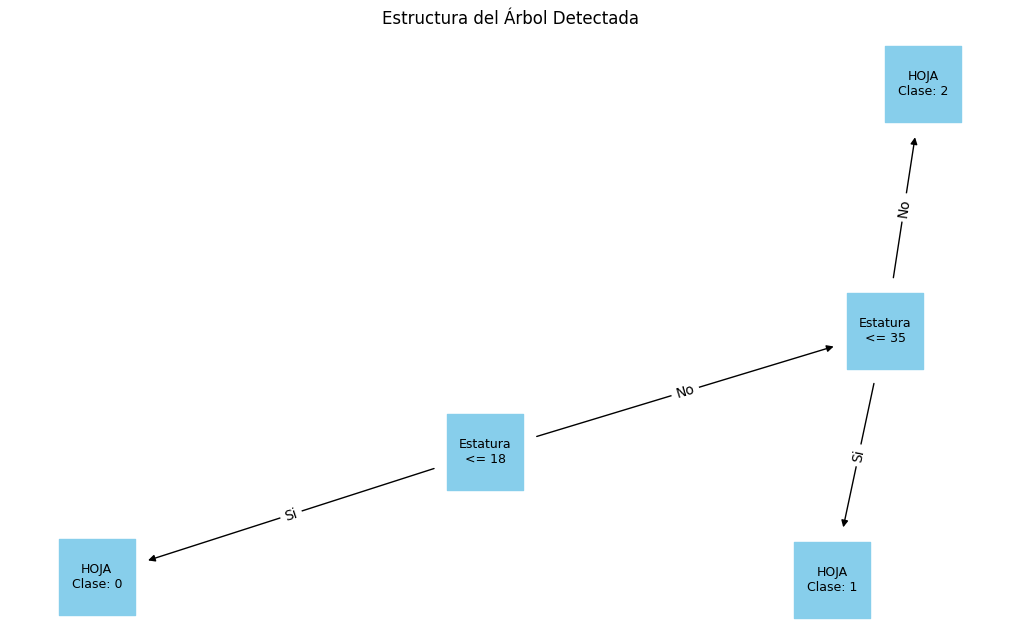

In [25]:
# --- Ejemplo de uso ---
if __name__ == "__main__":
    X_train = np.array([[15, 4], [18, 5], [20, 6], [35, 20], [40, 25], [45, 30]])
    y_train = np.array([0, 0, 1, 1, 2, 2])

    modelo = ArbolDecision(max_depth=2)
    modelo.fit(X_train, y_train)

    # Dibujamos usando la función externa pasándole la raíz
    dibujar_estructura_arbol(modelo.root, feature_names=["Estatura", "Peso"])

Predicción para [25 10]: Clase 1


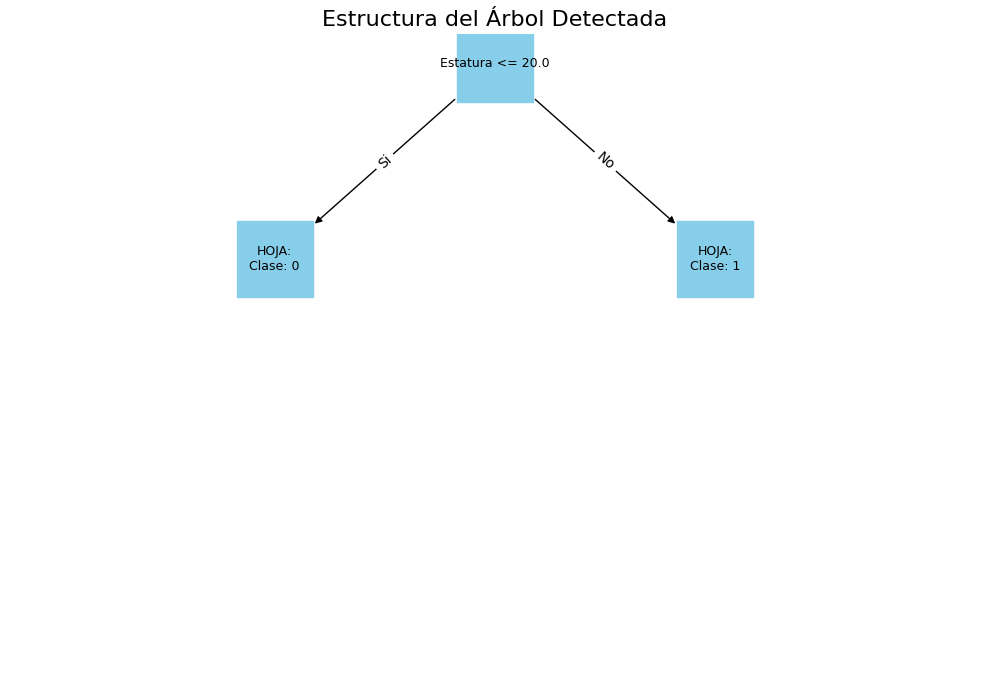

In [26]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================================
# --- REUTILIZAMOS TU CLASE NODO ORIGINAL (SIN CAMBIOS) ---
# ==========================================================
class Nodo:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

# ==========================================================
# --- NUEVA FUNCIÓN DE DIBUJO CON POSICIONAMIENTO LÓGICO ---
# ==========================================================

def _calcular_posiciones(nodo, x=0.5, y=1.0, width=0.5, current_depth=0, total_depth=1, node_positions={}, node_info={}):
    """
    Función recursiva para calcular las posiciones X e Y de un árbol balanceado.
    Calcula el espacio disponible para cada nodo y centra sus hijos.
    """
    if nodo is None:
        return node_positions, node_info

    # Asignar posición (X, Y)
    # X va de 0 a 1. Y va de 1 (raíz) a 0 (hojas más profundas).
    depth_factor = 1.0 / total_depth
    node_id = id(nodo) # Usamos el ID del objeto para NetworkX
    node_positions[node_id] = (x, 1.0 - (current_depth * depth_factor))

    # Guardar la información descriptiva del nodo (pregunta o clase)
    if nodo.value is not None:
        info_text = f"HOJA:\nClase: {nodo.value}"
    else:
        info_text = f"P: {nodo.feature} <= {nodo.threshold:.1f}" # P de Pregunta y formato .1f

    node_info[node_id] = {'label': info_text, 'type': 'leaf' if nodo.value is not None else 'split'}

    # Recursión para hijos
    next_y = y - depth_factor # Reducir Y para el siguiente nivel
    new_width = width / 2.0    # El espacio disponible se divide a la mitad

    if nodo.left:
        # Hijo izquierdo va a la izquierda (- ancho/2)
        _calcular_posiciones(nodo.left, x - new_width, next_y, new_width, current_depth + 1, total_depth, node_positions, node_info)

    if nodo.right:
        # Hijo derecho va a la derecha (+ ancho/2)
        _calcular_posiciones(nodo.right, x + new_width, next_y, new_width, current_depth + 1, total_depth, node_positions, node_info)

    return node_positions, node_info

def obtener_max_depth(nodo):
    """Calcula la profundidad máxima real del árbol."""
    if nodo is None or nodo.value is not None:
        return 0
    return 1 + max(obtener_max_depth(nodo.left), obtener_max_depth(nodo.right))

def dibujar_estructura_balanceada(nodo_raiz, feature_names, title="Estructura del Árbol Detectada"):
    """
    Función principal de visualización jerárquica y balanceada.
    Calcula las posiciones jerárquicas y dibuja el árbol.
    """
    if nodo_raiz is None:
        print("El árbol no ha sido entrenado o está vacío.")
        return

    # 1. Crear el grafo NetworkX y calcular posiciones lógicas
    grafo = nx.DiGraph()
    depth_real = obtener_max_depth(nodo_raiz)
    # depth + 2 para que las hojas no queden pegadas al borde inferior
    node_pos, node_data = _calcular_posiciones(nodo_raiz, total_depth=depth_real + 2)

    # 2. Re-etiquetar con nombres de características
    etiquetas_texto = {}
    for nid, data in node_data.items():
        if data['type'] == 'split':
            # Remplazar P:0 con Estatura:
            text = data['label']
            p_idx = text.split(":")[1].split("<")[0].strip() # Obtener el índice 0
            new_text = text.replace(f"P: {p_idx}", feature_names[int(p_idx)])
            etiquetas_texto[nid] = new_text
        else:
            etiquetas_texto[nid] = data['label']

    # 3. Añadir nodos y aristas al grafo de NetworkX
    grafo.add_nodes_from(node_pos.keys())

    def añadir_aristas(nodo, graph):
        if nodo is None or nodo.value is not None: return
        if nodo.left:
            graph.add_edge(id(nodo), id(nodo.left), label="Si")
            añadir_aristas(nodo.left, graph)
        if nodo.right:
            graph.add_edge(id(nodo), id(nodo.right), label="No")
            añadir_aristas(nodo.right, graph)

    añadir_aristas(nodo_raiz, grafo)

    # 4. Dibujar el árbol con Matplotlib
    plt.figure(figsize=(10, 7))
    plt.title(title, fontsize=16)

    # Dibujar nodos cuadrados y celestes, como en tu imagen
    nx.draw(grafo, node_pos, with_labels=False, node_size=3000,
            node_color="#87CEEB", node_shape='s', edge_color='black', arrows=True)

    # Dibujar etiquetas dentro de los nodos
    nx.draw_networkx_labels(grafo, node_pos, labels=etiquetas_texto, font_size=9)

    # Dibujar etiquetas de las aristas (Si/No)
    edge_labels = nx.get_edge_attributes(grafo, 'label')
    nx.draw_networkx_edge_labels(grafo, node_pos, edge_labels=edge_labels, font_size=10, font_color='black')

    # Configuración de ejes para que el layout se vea perfecto
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.axis('off') # Ocultar ejes de coordenadas
    plt.tight_layout()
    plt.show()

# ==========================================================
# --- BLOQUE PRINCIPAL DE EJECUCIÓN ---
# ==========================================================
if __name__ == "__main__":
    # 1. Dataset simple (Gatos vs Perros) [Estatura, Peso]
    X_train = np.array([[15, 4], [18, 5], [20, 6], [35, 20], [40, 25], [45, 30]])
    y_train = np.array([0, 0, 0, 1, 1, 1]) # 0: Gato, 1: Perro

    # 2. Entrenar el árbol
    # YA NO USAMOS 'from solution import...', usamos la clase que definimos arriba
    modelo = ArbolDecision(max_depth=3)
    modelo.fit(X_train, y_train)

    # 3. Clasificar un punto nuevo
    X_nuevo = np.array([[25, 10]])
    print(f"Predicción para {X_nuevo[0]}: Clase {modelo.predict(X_nuevo)[0]}")

    # 4. DIBUJAR EL ÁRBOL BALANCEADO
    # Usamos la función que creamos para que se vea ordenado
    dibujar_estructura_balanceada(modelo.root, feature_names=["Estatura", "Peso"])

#Random Forest

Aquí reutilizamos tu clase ArbolDecision (asegúrate de tenerla en el mismo script o importada).

In [27]:
import numpy as np
from collections import Counter

class RandomForest:
    def __init__(self, n_trees: int = 10, max_depth: int = 5,
                 n_features: int | None = None) -> None:
        """
        Inicializa el modelo Random Forest con número de árboles,
        profundidad máxima y número de características.
        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.n_features = n_features
        self.trees = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrena el modelo creando árboles de decisión sobre muestras bootstrap.
        """
        self.trees = []
        for _ in range(self.n_trees):
            # 1. Crear muestra Bootstrap
            n_samples = X.shape[0]
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X[indices], y[indices]

            # 2. Entrenar árbol (usando tu clase previa)
            # Nota: Para un RF real, el árbol debería elegir
            # características al azar en cada nodo.
            tree = ArbolDecision(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice las etiquetas para los datos de entrada mediante
        votación mayoritaria de los árboles.
        """
        # Obtener predicciones de cada árbol
        # tree_preds será una lista de arreglos: [[p1, p2], [p1, p2], ...]
        tree_preds = np.array([tree.predict(X) for tree in self.trees])

        # Transponer para tener las predicciones por cada punto: [[árbol1, árbol2], ...]
        tree_preds = np.swapaxes(tree_preds, 0, 1)

        # Votación mayoritaria
        predictions = [Counter(p).most_common(1)[0][0] for p in tree_preds]
        return np.array(predictions)

Visualización Independiente
Como Random Forest son muchos árboles, lo más didáctico es dibujar una "galería" de los primeros árboles para que  vean que efectivamente son diferentes entre sí.

In [28]:
def visualizar_bosque_completo(forest, feature_names, n_a_mostrar=3):
    """
    Muestra una hilera de árboles del bosque para comparar sus estructuras.
    """
    fig = plt.figure(figsize=(n_a_mostrar * 5, 5))

    for i in range(n_a_mostrar):
        # Crear un sub-eje para cada árbol
        ax = fig.add_subplot(1, n_a_mostrar, i + 1)

        # Obtenemos la raíz del árbol i-ésimo
        raiz_actual = forest.trees[i].root

        # Reutilizamos la lógica de cálculo de posiciones
        # Nota: He ajustado la función dibujar para que acepte un 'ax' específico
        dibujar_en_subfigura(raiz_actual, feature_names, ax, f"Árbol #{i+1}")

    plt.tight_layout()
    plt.show()

def dibujar_en_subfigura(nodo_raiz, feature_names, ax, titulo):
    """Versión simplificada de la función de dibujo para cuadrículas."""
    grafo = nx.DiGraph()
    depth_real = obtener_max_depth(nodo_raiz)
    node_pos, node_data = _calcular_posiciones(nodo_raiz, total_depth=depth_real + 2)

    # Construir etiquetas y aristas (mismo proceso que antes)
    etiquetas_texto = {nid: d['label'] for nid, d in node_data.items()}

    def añadir_aristas(nodo, graph):
        if nodo is None or nodo.value is not None: return
        if nodo.left:
            graph.add_edge(id(nodo), id(nodo.left), label="S")
            añadir_aristas(nodo.left, graph)
        if nodo.right:
            graph.add_edge(id(nodo), id(nodo.right), label="N")
            añadir_aristas(nodo.right, graph)

    añadir_aristas(nodo_raiz, grafo)

    # Dibujar en el eje 'ax' proporcionado
    nx.draw(grafo, node_pos, ax=ax, with_labels=False, node_size=1500,
            node_color="#87CEEB", node_shape='s', edge_color='gray', arrows=True)
    nx.draw_networkx_labels(grafo, node_pos, ax=ax, labels=etiquetas_texto, font_size=7)
    ax.set_title(titulo)
    ax.axis('off')

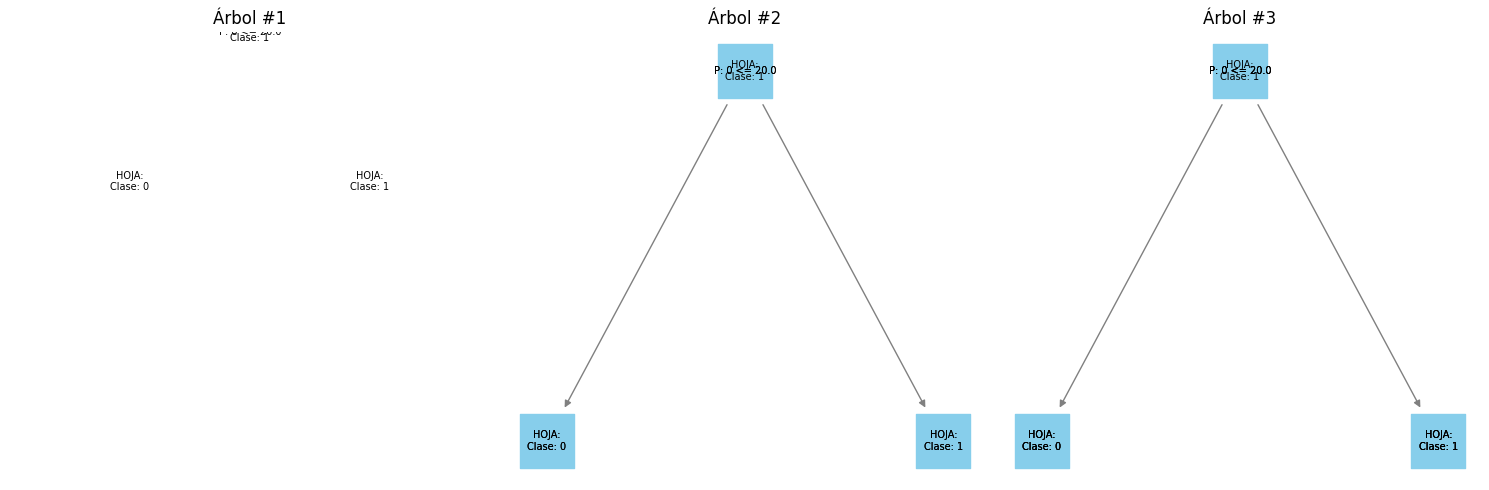

In [29]:
# Entrenamos el bosque
bosque = RandomForest(n_trees=10, max_depth=3)
bosque.fit(X_train, y_train)

# Visualizamos los primeros 3 para no saturar la pantalla
visualizar_bosque_completo(bosque, ["Estatura", "Peso"], n_a_mostrar=3)

# Gradient Boosting

Para que el Gradient Boosting funcione, nuestro ArbolDecision debe ser capaz de manejar valores continuos. Se ha simplificado la lógica del árbol para que use la Varianza como medida de impureza (que es el equivalente al MSE).

Ahora estamos haciendo regresión sobre los residuos, debemos cambiar la métrica del árbol. Ya no usaremos Entropía (que es para clasificación), sino el Error Cuadrático Medio (MSE).

In [30]:
import numpy as np
from collections import Counter

# ============================================================
# 1. Árbol de Decisión para REGRESIÓN (Maneja decimales)
# ============================================================
class Nodo:
    def __init__(self, feature: int | None = None, threshold: float | None = None,
                 left: "Nodo | None" = None, right: "Nodo | None" = None,
                 value: float | None = None) -> None:
        """
        Representa un nodo en el árbol de decisión para regresión.
        """
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class ArbolDecisionRegresor:
    def __init__(self, max_depth: int = 3) -> None:
        """
        Inicializa el árbol de decisión para regresión con profundidad máxima.
        """
        self.max_depth = max_depth
        self.root = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrena el árbol de decisión utilizando los datos de entrada.
        """
        self.root = self._crear_arbol(X, y, depth=0)

    def _crear_arbol(self, X: np.ndarray, y: np.ndarray, depth: int) -> Nodo:
        """
        Construye recursivamente el árbol de decisión para regresión.
        """
        n_samples = len(y)
        # Si llegamos al tope o hay muy pocos datos, la hoja es el PROMEDIO de los residuos
        if depth >= self.max_depth or n_samples < 2:
            return Nodo(value=np.mean(y))

        best_feat, best_thresh = self._mejor_criterio(X, y)
        if best_feat is None:
            return Nodo(value=np.mean(y))

        left_idx = X[:, best_feat] <= best_thresh
        right_idx = ~left_idx

        izq = self._crear_arbol(X[left_idx], y[left_idx], depth + 1)
        der = self._crear_arbol(X[right_idx], y[right_idx], depth + 1)
        return Nodo(feature=best_feat, threshold=best_thresh, left=izq, right=der)

    def _mejor_criterio(self, X: np.ndarray, y: np.ndarray) -> tuple[int | None, float | None]:
        """
        Encuentra la mejor característica y umbral minimizando el MSE.
        """
        best_mse = np.var(y) # Error inicial
        split_idx, split_thresh = None, None

        for feat_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feat_idx])
            for threshold in thresholds:
                left_y = y[X[:, feat_idx] <= threshold]
                right_y = y[X[:, feat_idx] > threshold]

                if len(left_y) == 0 or len(right_y) == 0: continue

                # Calculamos la varianza ponderada (MSE)
                mse_actual = (len(left_y)*np.var(left_y) + len(right_y)*np.var(right_y)) / len(y)

                if mse_actual < best_mse:
                    best_mse = mse_actual
                    split_idx = feat_idx
                    split_thresh = threshold
        return split_idx, split_thresh

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice valores para los datos de entrada usando el árbol entrenado.
        """
        return np.array([self._recorrer_arbol(x, self.root) for x in X])

    def _recorrer_arbol(self, x: np.ndarray, nodo: Nodo) -> float:
        """
        Recorre el árbol para predecir el valor de una muestra.
        """
        if nodo.value is not None: return nodo.value
        if x[nodo.feature] <= nodo.threshold:
            return self._recorrer_arbol(x, nodo.left)
        return self._recorrer_arbol(x, nodo.right)

# ============================================================
# 2. Gradient Boosting (Ahora sí, usando el regresor)
# ============================================================
class GradientBoostingDesdeCero:
    def __init__(self, n_estimators: int = 10,
                 learning_rate: float = 0.1, max_depth: int = 3) -> None:
        """
        Inicializa el modelo de Gradient Boosting con número de estimadores,
        tasa de aprendizaje y profundidad máxima.
        """
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.init_prediction = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrena el modelo de Gradient Boosting ajustando secuencialmente
        árboles sobre los residuos.
        """
        # Aseguramos que y sea float para evitar errores de tipos
        y = y.astype(float)
        self.init_prediction = np.mean(y)
        f_m = np.full(y.shape, self.init_prediction)

        for _ in range(self.n_estimators):
            residuos = y - f_m

            # Usamos nuestro nuevo regresor que aguanta decimales
            tree = ArbolDecisionRegresor(max_depth=self.max_depth)
            tree.fit(X, residuos)

            f_m += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice valores continuos acumulando las contribuciones
        de todos los árboles entrenados.
        """
        y_pred = np.full(X.shape[0], self.init_prediction)
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred


# --- Prueba sin Errores ---
if __name__ == "__main__":
    X = np.array([[1], [2], [3], [4], [5]])
    y = np.array([2, 4, 6, 8, 10])

    gb = GradientBoostingDesdeCero(n_estimators=50, learning_rate=0.1)
    gb.fit(X, y)

    test_val = np.array([[6]])
    print(f"Predicción para x=6: {gb.predict(test_val)[0]:.2f}")

Predicción para x=6: 9.98


# XGBoost

Implementaremos la Regularización L2 ($\lambda$) sobre nuestro regresor de residuos, que es el alma de XGBoost.

In [31]:
import numpy as np

class XGBoostMiniDesdeCero:
    def __init__(self, n_estimators: int = 10, learning_rate: float = 0.1,
                 max_depth: int = 3, reg_lambda: float = 1.0) -> None:
        """
        Inicializa el modelo tipo XGBoost con número de estimadores,
        tasa de aprendizaje, profundidad máxima y regularización L2.
        """
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda # Término de regularización L2
        self.trees = []
        self.init_prediction = 0

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Entrena el modelo ajustando árboles sobre los residuos con regularización.
        """
        # 1. Inicialización
        self.init_prediction = np.mean(y)
        f_m = np.full(y.shape, self.init_prediction)

        for _ in range(self.n_estimators):
            # En XGBoost, calculamos gradientes (g) y hessianos (h)
            # Para MSE: g = -(y - f_m), h = 1 (constante)
            residuos = y - f_m

            # Entrenamos un árbol que considera la regularización lambda
            tree = ArbolDecisionRegresorRegularizado(
                max_depth=self.max_depth,
                reg_lambda=self.reg_lambda
            )
            tree.fit(X, residuos)

            # Actualización
            f_m += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predice valores acumulando las contribuciones de los árboles entrenados.
        """
        y_pred = np.full(X.shape[0], self.init_prediction)
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred


# Modificamos ligeramente el regresor para incluir la "fuerza" de lambda
class ArbolDecisionRegresorRegularizado(ArbolDecisionRegresor):
    def __init__(self, max_depth: int = 3, reg_lambda: float = 1.0) -> None:
        """
        Inicializa un árbol de regresión con regularización
        L2 en los valores de hoja.
        """
        super().__init__(max_depth)
        self.reg_lambda = reg_lambda

    def _crear_arbol(self, X: np.ndarray, y: np.ndarray, depth: int) -> Nodo:
        """
        Construye el árbol aplicando regularización
        en el cálculo del valor de las hojas.
        """
        # El valor de la hoja en XGBoost está regularizado: sum(g) / (sum(h) + lambda)
        # Para MSE simplificado es: mean(y) * (n / (n + lambda))
        if depth >= self.max_depth or len(y) < 2:
            peso_regularizado = np.sum(y) / (len(y) + self.reg_lambda)
            return Nodo(value=peso_regularizado)

        return super()._crear_arbol(X, y, depth)

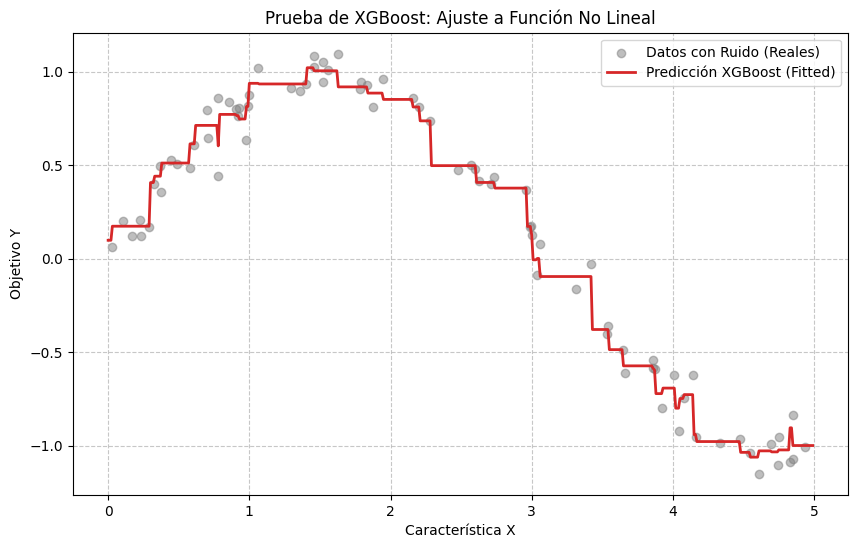

In [32]:
import matplotlib.pyplot as plt

def probar_xgboost_vs_realidad():
    # 1. Crear datos: Una curva seno con un poco de "ruido"
    # Esto simula datos reales que no son perfectamente lineales
    np.random.seed(42)
    X = np.sort(5 * np.random.rand(80, 1), axis=0)
    y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

    # 2. Instanciar y entrenar nuestro XGBoost "Mini"
    # Prueba variando reg_lambda: si es 0, se sobreajusta; si es alto, es más suave
    modelo = XGBoostMiniDesdeCero(n_estimators=30, learning_rate=0.2, max_depth=3, reg_lambda=1.0)
    modelo.fit(X, y)

    # 3. Generar predicciones para visualizar la curva
    X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
    y_pred = modelo.predict(X_test)

    # 4. Graficar los resultados
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color="tab:gray", alpha=0.5, label="Datos con Ruido (Reales)")
    plt.plot(X_test, y_pred, color="tab:red", linewidth=2, label="Predicción XGBoost (Fitted)")
    plt.title("Prueba de XGBoost: Ajuste a Función No Lineal")
    plt.xlabel("Característica X")
    plt.ylabel("Objetivo Y")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

if __name__ == "__main__":
    probar_xgboost_vs_realidad()

# K-means

In [33]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    def __init__(self, K: int = 3, max_iters: int = 100) -> None:
        """
        Inicializa el modelo K-Means con número de clusters y máximo de iteraciones.
        """
        self.K = K
        self.max_iters = max_iters
        self.centroids = None
        self.clusters = [[] for _ in range(self.K)]

    def fit(self, X: np.ndarray) -> None:
        """
        Entrena el modelo K-Means ajustando centroides y clusters a los datos.
        """
        self.X = X
        self.n_samples, self.n_features = X.shape

        # 1. Inicializar centroides aleatorios (tomando puntos del dataset)
        random_sample_idxs = np.random.choice(self.n_samples, self.K, replace=False)
        self.centroids = self.X[random_sample_idxs]

        for _ in range(self.max_iters):
            # 2. Asignación: Crear clusters basados en el centroide más cercano
            self.clusters = self._create_clusters(self.centroids)

            # Guardar centroides viejos para checar convergencia
            centroids_old = self.centroids

            # 3. Actualización: Calcular nuevos centroides (promedio de los puntos)
            self.centroids = self._get_centroids(self.clusters)

            # Si los centroides no cambian, terminamos (convergencia)
            if self._is_converged(centroids_old, self.centroids):
                break

    def _create_clusters(self, centroids: np.ndarray) -> list[list[int]]:
        """
        Asigna cada muestra al cluster cuyo centroide es más cercano.
        """
        clusters = [[] for _ in range(self.K)]
        for idx, sample in enumerate(self.X):
            # Calculamos distancia a todos los centroides
            distances = [np.sqrt(np.sum((sample - c)**2)) for c in centroids]
            # Nos quedamos con el índice del más cercano
            closest_idx = np.argmin(distances)
            clusters[closest_idx].append(idx)
        return clusters

    def _get_centroids(self, clusters: list[list[int]]) -> np.ndarray:
        """
        Calcula los nuevos centroides como el promedio de los puntos en cada cluster.
        """
        centroids = np.zeros((self.K, self.n_features))
        for cluster_idx, cluster in enumerate(clusters):
            if not cluster: # Evitar división por cero si un cluster queda vacío
                centroids[cluster_idx] = self.X[np.random.choice(self.n_samples)]
            else:
                cluster_mean = np.mean(self.X[cluster], axis=0)
                centroids[cluster_idx] = cluster_mean
        return centroids

    def _is_converged(self, centroids_old: np.ndarray, centroids_new: np.ndarray) -> bool:
        """
        Determina si los centroides han convergido comparando su desplazamiento.
        """
        distances = [np.sqrt(np.sum((centroids_old[i] - centroids_new[i])**2)) for i in range(self.K)]
        return sum(distances) == 0

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Asigna nuevos datos al cluster más cercano según los centroides entrenados.
        """
        # Para datos nuevos, solo vemos a qué centroide entrenado están más cerca
        distances = [np.sqrt(np.sum((X - c)**2, axis=1)) for c in self.centroids]
        return np.argmin(distances, axis=0)


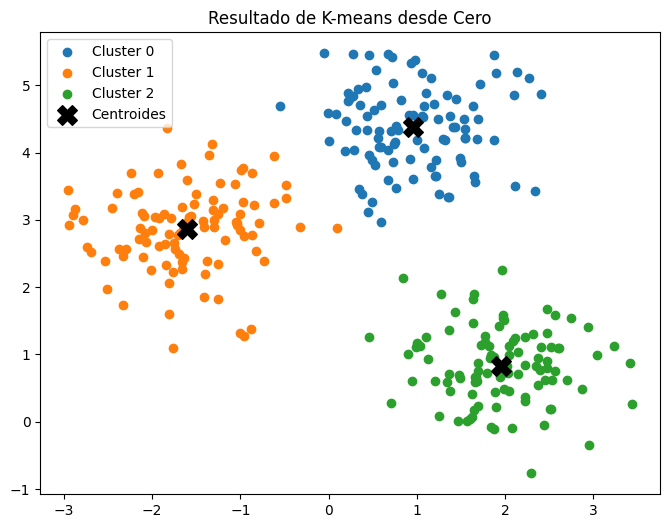

In [34]:
# --- Prueba para el laboratorio ---
if __name__ == "__main__":
    # Crear datos sintéticos (3 grupos claros)
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

    # Entrenar modelo
    km = KMeans(K=3)
    km.fit(X)

    # Graficar
    plt.figure(figsize=(8, 6))
    for i, cluster in enumerate(km.clusters):
        points = X[cluster]
        plt.scatter(points[:, 0], points[:, 1], label=f"Cluster {i}")

    # Dibujar los centroides finales
    plt.scatter(km.centroids[:, 0], km.centroids[:, 1], s=200, c='black', marker='X', label="Centroides")
    plt.title("Resultado de K-means desde Cero")
    plt.legend()
    plt.show()

#DBSCAN

In [35]:
import numpy as np
import matplotlib.pyplot as plt

class DBSCAN:
    def __init__(self, eps: float = 0.5, min_samples: int = 5) -> None:
        """
        Inicializa el algoritmo DBSCAN con radio de vecindad y mínimo de muestras.
        """
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None

    def fit(self, X: np.ndarray) -> np.ndarray:
        """
        Ajusta el modelo DBSCAN a los datos y asigna etiquetas de clusters.
        """
        n_samples = X.shape[0]
        self.labels = np.full(n_samples, -1) # -1 significa ruido inicialmente
        visited = np.zeros(n_samples, dtype=bool)
        cluster_id = 0

        for i in range(n_samples):
            if visited[i]:
                continue

            visited[i] = True
            neighbors = self._get_neighbors(X, i)

            if len(neighbors) < self.min_samples:
                self.labels[i] = -1 # Marcado como ruido
            else:
                self._expand_cluster(X, i, neighbors, cluster_id, visited)
                cluster_id += 1
        return self.labels

    def _get_neighbors(self, X: np.ndarray, target_idx: int) -> np.ndarray:
        """
        Encuentra los índices de los puntos vecinos dentro del radio eps.
        """
        # Calculamos distancia euclidiana simple
        distances = np.linalg.norm(X - X[target_idx], axis=1)
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self, X: np.ndarray, root_idx: int, neighbors: np.ndarray,
                        cluster_id: int, visited: np.ndarray) -> None:
        """
        Expande un cluster agregando puntos densamente conectados.
        """
        self.labels[root_idx] = cluster_id

        # Usamos una lista dinámica para simular la cola de expansión
        queue = list(neighbors)

        while queue:
            current_p = queue.pop(0)

            if not visited[current_p]:
                visited[current_p] = True
                current_neighbors = self._get_neighbors(X, current_p)

                if len(current_neighbors) >= self.min_samples:
                    queue.extend(current_neighbors)

            if self.labels[current_p] == -1:
                self.labels[current_p] = cluster_id


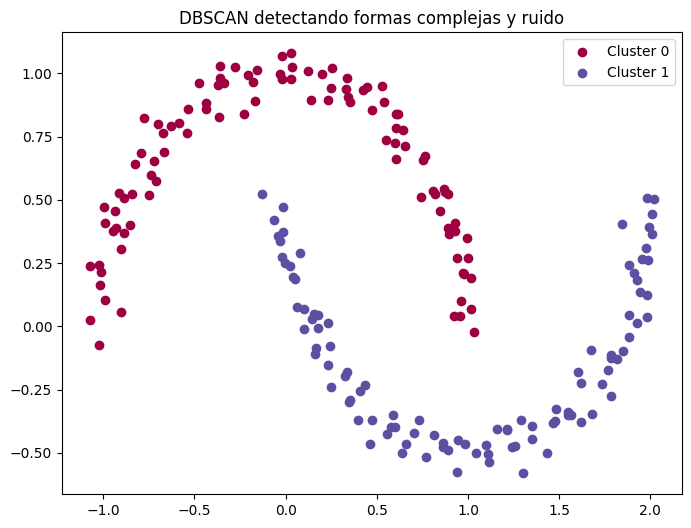

In [36]:
# --- Prueba para el laboratorio (Formas no circulares) ---
if __name__ == "__main__":
    from sklearn.datasets import make_moons
    # Creamos dos lunas (K-means fallaría aquí)
    X, _ = make_moons(n_samples=200, noise=0.05, random_state=0)

    # Entrenar DBSCAN
    db = DBSCAN(eps=0.2, min_samples=5)
    labels = db.fit(X)

    # Graficar
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'black' # Ruido en negro

        class_member_mask = (labels == k)
        plt.scatter(X[class_member_mask, 0], X[class_member_mask, 1],
                    c=[col], label=f"Cluster {k}" if k != -1 else "Ruido")

    plt.title("DBSCAN detectando formas complejas y ruido")
    plt.legend()
    plt.show()

#Hierarchical Clustering

In [37]:
import numpy as np
import matplotlib.pyplot as plt

class HierarchicalClustering:
    def __init__(self, n_clusters: int = 2) -> None:
        """
        Inicializa el modelo de clustering jerárquico con
        el número de clusters deseado.
        """
        self.n_clusters = n_clusters
        self.history = []

    def fit(self, X: np.ndarray) -> np.ndarray:
        """
        Ajusta el modelo agrupando iterativamente
        los clusters más cercanos.
        """
        # 1. Cada punto empieza como un cluster individual
        # clusters es una lista de listas con los índices de los puntos
        clusters = [[i] for i in range(len(X))]

        while len(clusters) > self.n_clusters:
            min_dist = float('inf')
            pair = (0, 0)

            # 2. Buscar los dos clusters más cercanos (Single Linkage)
            for i in range(len(clusters)):
                for j in range(i + 1, len(clusters)):
                    dist = self._distancia_entre_clusters(X, clusters[i], clusters[j])
                    if dist < min_dist:
                        min_dist = dist
                        pair = (i, j)

            # 3. Fusionar los clusters encontrados
            c1_idx, c2_idx = pair
            new_cluster = clusters[c1_idx] + clusters[c2_idx]

            # Actualizar la lista de clusters
            clusters.pop(c2_idx) # Eliminar el de mayor índice primero
            clusters.pop(c1_idx)
            clusters.append(new_cluster)

        self.labels_ = self._get_labels(len(X), clusters)
        return self.labels_

    def _distancia_entre_clusters(self, X: np.ndarray, c1: list[int],
                                  c2: list[int]) -> float:
        """
        Calcula la distancia mínima entre dos clusters usando single linkage.
        """
        # Single Linkage: Distancia mínima entre cualquier par de puntos
        dists = []
        for i in c1:
            for j in c2:
                dists.append(np.linalg.norm(X[i] - X[j]))
        return min(dists)

    def _get_labels(self, n_samples: int, clusters: list[list[int]]) -> np.ndarray:
        """
        Genera etiquetas para cada muestra según el cluster al que pertenece.
        """
        labels = np.zeros(n_samples, dtype=int)
        for cluster_idx, cluster in enumerate(clusters):
            for point_idx in cluster:
                labels[point_idx] = cluster_idx
        return labels

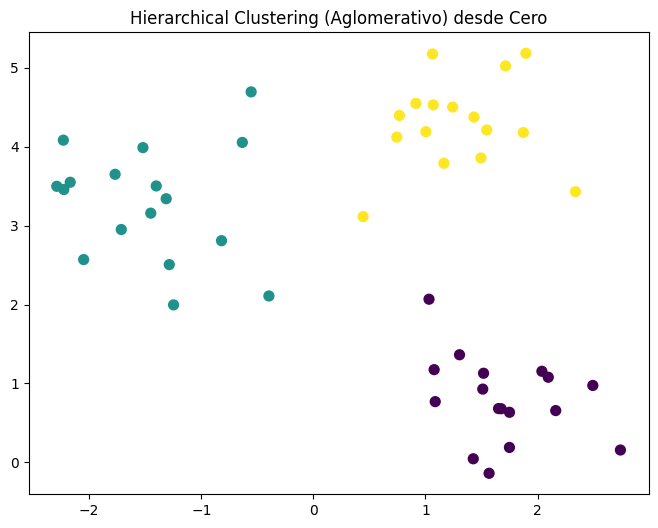

In [38]:

# --- Prueba para el laboratorio ---
if __name__ == "__main__":
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.6, random_state=0)

    # Entrenar modelo
    hc = HierarchicalClustering(n_clusters=3)
    labels = hc.fit(X)

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    plt.title("Hierarchical Clustering (Aglomerativo) desde Cero")
    plt.show()

#Isolation Forest

In [39]:
import numpy as np

class iTree:
    def __init__(self, X: np.ndarray, depth: int, limit: int) -> None:
        """
        Construye un árbol de aislamiento recursivamente para dividir los datos.
        """
        self.size = len(X)
        self.node_type = 'leaf'
        if depth < limit and self.size > 1:
            self.node_type = 'split'
            self.feature = np.random.randint(0, X.shape[1])
            split_min, split_max = X[:, self.feature].min(), X[:, self.feature].max()

            if split_min != split_max:
                self.threshold = np.random.uniform(split_min, split_max)
                left_idx = X[:, self.feature] < self.threshold
                self.left = iTree(X[left_idx], depth + 1, limit)
                self.right = iTree(X[~left_idx], depth + 1, limit)
            else:
                self.node_type = 'leaf'


def path_length(x: np.ndarray, tree: iTree, current_height: int) -> float:
    """
    Calcula la longitud del camino de un punto dentro de un árbol de aislamiento.
    """
    if tree.node_type == 'leaf':
        # Factor de ajuste c(size) para nodos hoja con más de 1 punto
        return current_height + (c_factor(tree.size) if tree.size > 1 else 0)

    if x[tree.feature] < tree.threshold:
        return path_length(x, tree.left, current_height + 1)
    else:
        return path_length(x, tree.right, current_height + 1)


def c_factor(n: int) -> float:
    """
    Calcula el factor de normalización usado en Isolation Forest.
    """
    return 2.0 * (np.log(n - 1) + 0.5772156649) - (2.0 * (n - 1.) / n)


class IsolationForest:
    def __init__(self, n_trees: int = 100, sample_size: int = 256) -> None:
        """
        Inicializa el modelo Isolation Forest con
        número de árboles y tamaño de muestra.
        """
        self.n_trees = n_trees
        self.sample_size = sample_size
        self.trees = []
        self.limit = int(np.ceil(np.log2(sample_size)))

    def fit(self, X: np.ndarray) -> None:
        """
        Entrena el modelo construyendo múltiples árboles de aislamiento.
        """
        self.trees = []
        for _ in range(self.n_trees):
            # Tomar submuestra aleatoria
            idxs = np.random.choice(len(X), self.sample_size, replace=False)
            tree = iTree(X[idxs], 0, self.limit)
            self.trees.append(tree)

    def anomaly_score(self, X: np.ndarray) -> np.ndarray:
        """
        Calcula el puntaje de anomalía para cada muestra en función
        de la longitud promedio de caminos.
        """
        scores = []
        for x in X:
            lengths = [path_length(x, t, 0) for t in self.trees]
            avg_length = np.mean(lengths)
            # Formula del score s = 2 ^ (-E(h(x)) / c(sample_size))
            score = 2**(-avg_length / c_factor(self.sample_size))
            scores.append(score)
        return np.array(scores)


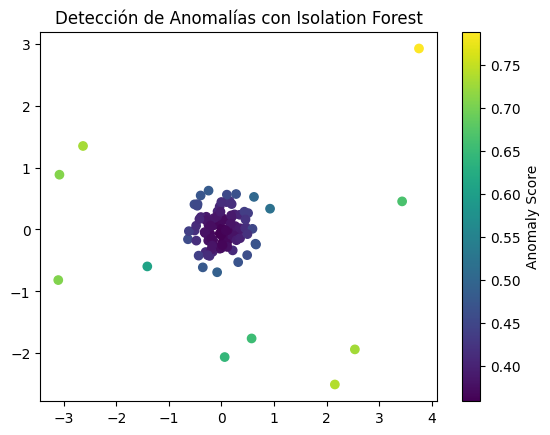

In [40]:

# --- Prueba de Laboratorio ---
if __name__ == "__main__":
    # Generar datos normales
    X_normal = 0.3 * np.random.randn(100, 2)
    # Generar anomalías (puntos alejados)
    X_outliers = np.random.uniform(low=-4, high=4, size=(10, 2))
    X = np.r_[X_normal, X_outliers]

    iforest = IsolationForest(n_trees=100, sample_size=64)
    iforest.fit(X)
    scores = iforest.anomaly_score(X)

    # Visualizar
    import matplotlib.pyplot as plt
    plt.scatter(X[:, 0], X[:, 1], c=scores, cmap='viridis')
    plt.colorbar(label='Anomaly Score')
    plt.title("Detección de Anomalías con Isolation Forest")
    plt.show()

# Red Básica CNN
Un esqueleto funcional de una CNN muy básica (para MNIST, por ejemplo). Está simplificado el Backpropagation de la convolución para que sea legible, pero el concepto es el mismo.

Nota para la clase: Este código es didáctico. Para producción, nunca lo usaríamos porque NumPy corre en CPU y las CNN necesitan GPUs.

In [41]:
import numpy as np

# ==========================================
# 1. Capa de Convolución (Didáctica)
# ==========================================
class CapaConvolucion:
    def __init__(self, num_filtros, tamaño_kernel):
        self.num_filtros = num_filtros
        self.tamaño_kernel = tamaño_kernel
        # Inicialización de filtros al azar, normalizados
        self.filtros = np.random.randn(num_filtros, tamaño_kernel, tamaño_kernel) / (tamaño_kernel**2)

    def _obtener_regiones(self, imagen):
        h, w = imagen.shape
        for i in range(h - self.tamaño_kernel + 1):
            for j in range(w - self.tamaño_kernel + 1):
                region = imagen[i:(i + self.tamaño_kernel), j:(j + self.tamaño_kernel)]
                yield region, i, j

    def forward(self, entrada):
        self.ultima_entrada = entrada
        h, w = entrada.shape
        salida = np.zeros((h - self.tamaño_kernel + 1, w - self.tamaño_kernel + 1, self.num_filtros))

        for region, i, j in self._obtener_regiones(entrada):
            # Operación de convolución: suma del producto punto
            salida[i, j] = np.sum(region * self.filtros, axis=(1, 2))
        return salida

    def backward(self, d_L_d_salida, learning_rate):
        # --- EL RETO MATEMÁTICO ---
        # Calculamos el gradiente del error con respecto a los filtros
        d_L_d_filtros = np.zeros(self.filtros.shape)
        for region, i, j in self._obtener_regiones(self.ultima_entrada):
            for f in range(self.num_filtros):
                d_L_d_filtros[f] += region * d_L_d_salida[i, j, f]

        # Actualizamos los filtros usando descenso de gradiente
        self.filtros -= learning_rate * d_L_d_filtros
        # (Aquí faltaría calcular d_L_d_entrada para propagar el error atrás,
        # pero para una CNN simple de una capa lo omitimos para claridad)
        return None

# ==========================================
# 2. Capa de Max Pooling
# ==========================================
class CapaMaxPooling:
    def __init__(self, tamaño_pool=2):
        self.tamaño_pool = tamaño_pool

    def _obtener_regiones(self, imagen):
        h, w, num_filtros = imagen.shape
        nuevo_h = h // self.tamaño_pool
        nuevo_w = w // self.tamaño_pool
        for i in range(nuevo_h):
            for j in range(nuevo_w):
                region = imagen[(i * self.tamaño_pool):(i * self.tamaño_pool + self.tamaño_pool),
                                (j * self.tamaño_pool):(j * self.tamaño_pool + self.tamaño_pool)]
                yield region, i, j

    def forward(self, entrada):
        self.ultima_entrada = entrada
        h, w, num_filtros = entrada.shape
        salida = np.zeros((h // self.tamaño_pool, w // self.tamaño_pool, num_filtros))

        for region, i, j in self._obtener_regiones(entrada):
            salida[i, j] = np.amax(region, axis=(0, 1))
        return salida

    def backward(self, d_L_d_salida):
        # --- EL RETO MATEMÁTICO ---
        # Solo el píxel que fue el máximo recibe el error
        d_L_d_entrada = np.zeros(self.ultima_entrada.shape)
        for region, i, j in self._obtener_regiones(self.ultima_entrada):
            h, w, f = region.shape
            amax = np.amax(region, axis=(0, 1))

            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):
                        if region[i2, j2, f2] == amax[f2]:
                            d_L_d_entrada[i*self.tamaño_pool+i2, j*self.tamaño_pool+j2, f2] = d_L_d_salida[i, j, f2]
        return d_L_d_entrada

# ==========================================
# 3. Capa Softmax (Para la salida densa final)
# ==========================================
class CapaSoftmax:
    def __init__(self, tamaño_entrada, tamaño_salida):
        self.pesos = np.random.randn(tamaño_entrada, tamaño_salida) / tamaño_entrada
        self.biases = np.zeros(tamaño_salida)

    def forward(self, entrada):
        self.ultima_entrada_shape = entrada.shape
        entrada_aplanada = entrada.flatten()
        self.ultima_entrada_aplanada = entrada_aplanada

        totales = np.dot(entrada_aplanada, self.pesos) + self.biases
        exp = np.exp(totales)
        self.ultima_salida = exp / np.sum(exp, axis=0)
        return self.ultima_salida

    def backward(self, d_L_d_salida, learning_rate):
        # --- EL RETO MATEMÁTICO ---
        # Calculamos gradientes para la capa densa final
        for i, gradiente in enumerate(d_L_d_salida):
            if gradiente == 0: continue

            t_exp = np.exp(self.ultima_salida)
            S_total = np.sum(t_exp)

            # Gradiente de softmax con respecto a los totales
            d_out_d_t = -t_exp[i] * t_exp / (S_total**2)
            d_out_d_t[i] = t_exp[i] * (S_total - t_exp[i]) / (S_total**2)

            # Gradiente de error con respecto a los totales
            d_L_d_t = gradiente * d_out_d_t

            # Gradientes de error con respecto a pesos/biases/entrada
            d_t_d_w = self.ultima_entrada_aplanada
            d_t_d_b = 1
            d_t_d_inputs = self.pesos

            # Actualizamos pesos y biases
            self.pesos -= learning_rate * np.dot(d_t_d_w[np.newaxis].T, d_L_d_t[np.newaxis])
            self.biases -= learning_rate * d_t_d_b * d_L_d_t

            # Retornamos el gradiente de error con respecto a la entrada (para la capa anterior)
            return np.dot(d_t_d_inputs, d_L_d_t).reshape(self.ultima_entrada_shape)

# ==========================================
# 4. Probando la CNN "Frankenstein"
# ==========================================
if __name__ == "__main__":
    # Creamos una imagen sintética de 28x28 (tipo MNIST)
    imagen = np.random.rand(28, 28)
    etiqueta = np.zeros(10)
    etiqueta[5] = 1 # Supongamos que es el número '5'

    # Instanciamos nuestras capas
    conv = CapaConvolucion(num_filtros=8, tamaño_kernel=3)
    pool = CapaMaxPooling(tamaño_pool=2)
    # 28-3+1 = 26. 26/2 = 13. 13*13*8 = 1352 neuronas de entrada densa
    softmax = CapaSoftmax(tamaño_entrada=13*13*8, tamaño_salida=10)

    # --- FORWARD PASS ---
    out_conv = conv.forward(imagen)
    out_pool = pool.forward(out_conv)
    prediccion = softmax.forward(out_pool)
    print("Predicción (probabilidades):", np.round(prediccion, 2))

    # --- CALCULO DE PÉRDIDA ---
    loss = -np.log(prediccion[np.argmax(etiqueta)])
    print("Pérdida (Cross-Entropy):", loss)

    # --- BACKWARD PASS ---
    # Gradiente inicial del error con respecto a la salida
    gradient = np.zeros(10)
    gradient[np.argmax(etiqueta)] = -1 / prediccion[np.argmax(etiqueta)]

    grad_softmax = softmax.backward(gradient, learning_rate=0.01)
    grad_pool = pool.backward(grad_softmax)
    conv.backward(grad_pool, learning_rate=0.01)
    print("Pesos actualizados. ¡La CNN aprendió un poquito!")

Predicción (probabilidades): [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Pérdida (Cross-Entropy): 2.3003209954025707
Pesos actualizados. ¡La CNN aprendió un poquito!



Es el momento perfecto para que observen el valor de la Pérdida (Cross-Entropy).
En tu ejecución marcó 2.30; si lo corrieran en un ciclo de entrenamiento real (un loop de muchas épocas), verían cómo ese número baja mientras las probabilidades de la clase correcta suben.

Resumen de las Redes Neuronales Convolucionales (CNN) :

- CNN: El Algoritmo Formal

  Una Red Neuronal Convolucional es un modelo de aprendizaje profundo diseñado para procesar datos con una topología de cuadrícula conocida (como imágenes). Su arquitectura formal se basa en tres tipos de capas:
    - Capa de Convolución ($L_{conv}$):
      
      - Utiliza un conjunto de filtros (kernels) aprendibles.
      - Propiedad Matemática: Realiza el producto escalar entre los pesos del filtro y una pequeña región de la entrada, permitiendo el compartimiento de pesos (weight sharing).
      
    - Capa de Activación:
      - Usualmente ReLU ($f(x) = \max(0, x)$), que introduce no linealidad al sistema.
      - Capa de Pooling ($L_{pool}$):
        - Reduce la dimensionalidad espacial (ancho x alto) para disminuir el número de parámetros y controlar el sobreajuste.
        - El Max Pooling selecciona el valor máximo de una región, proporcionando invarianza a pequeñas traslaciones.
    - Capas Totalmente Conectadas ($L_{fc}$):
    
      - Aplanan el volumen de datos para realizar la clasificación final mediante una función Softmax.
      
- Métricas de Complejidad
  - Complejidad en Tiempo (Entrenamiento): $O(\sum_{l=1}^{d} n_{l-1} \cdot s_l^2 \cdot n_l \cdot m_l^2)$, donde $d$ es la profundidad, $n$ es el número de filtros, $s$ es el tamaño del kernel y $m$ es el tamaño de la imagen de salida.
  - Complejidad en Espacio: $O(\sum_{l=1}^{d} n_{l-1} \cdot s_l^2 \cdot n_l)$. Es notablemente eficiente ya que los parámetros no dependen del tamaño de la imagen de entrada, sino del tamaño de los filtros.
  
**Comentario para el Cierre de Clase**

Lo que acaban de hacer manualmente —calcular el gradiente para actualizar los filtros— es el alma de la visión artificial moderna. Este mismo principio, escalado a millones de parámetros y capas, es lo que permite que una IA reconozca rostros o asista en diagnósticos médicos por imagen.

#Q-Learning

In [42]:
import numpy as np

class QLearningAgente:
    def __init__(self, n_estados, n_acciones, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.q_table = np.zeros((n_estados, n_acciones))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def elegir_accion(self, estado):
        # Estrategia Epsilon-Greedy (Exploración vs Explotación)
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.choice(self.q_table.shape[1]) # Explorar
        else:
            return np.argmax(self.q_table[estado]) # Explotar

    def aprender(self, estado, accion, recompensa, proximo_estado):
        # Aplicamos la Ecuación de Bellman
        valor_actual = self.q_table[estado, accion]
        mejor_proximo_valor = np.max(self.q_table[proximo_estado])

        # Actualización de la Q-Table
        nuevo_valor = valor_actual + self.alpha * (recompensa + self.gamma * mejor_proximo_valor - valor_actual)
        self.q_table[estado, accion] = nuevo_valor

# --- Ejemplo de Uso ---
if __name__ == "__main__":
    # Supongamos un mundo de 5 estados y 2 acciones (Izquierda, Derecha)
    agente = QLearningAgente(n_estados=5, n_acciones=2)

    # Simulación de un paso
    estado_actual = 0
    accion = agente.elegir_accion(estado_actual)
    recompensa = 1 # El agente encontró un premio
    proximo_estado = 1

    agente.aprender(estado_actual, accion, recompensa, proximo_estado)
    print("Q-Table Actualizada:\n", agente.q_table)

Q-Table Actualizada:
 [[0.1 0. ]
 [0.  0. ]
 [0.  0. ]
 [0.  0. ]
 [0.  0. ]]


In [43]:
if __name__ == "__main__":
    # Mundo de 5 estados (0 es el inicio, 4 es la meta con premio)
    agente = QLearningAgente(n_estados=5, n_acciones=2)

    # Entrenamos por 1000 episodios
    for episodio in range(5000):
        estado = 0 # Empezar siempre al inicio
        while estado < 4: # Hasta llegar a la meta
            accion = agente.elegir_accion(estado)

            # Definimos la lógica del mundo:
            # Acción 1 (derecha) avanza, Acción 0 (izquierda) retrocede o se queda igual
            proximo_estado = min(4, estado + 1) if accion == 1 else max(0, estado - 1)

            # Recompensa: Solo si llega al estado 4
            recompensa = 10 if proximo_estado == 4 else -1 # Penalizamos por perder tiempo

            agente.aprender(estado, accion, recompensa, proximo_estado)
            estado = proximo_estado

    print("Q-Table con Conocimiento (Tras 1000 intentos):")
    print(agente.q_table)

Q-Table con Conocimiento (Tras 1000 intentos):
[[ 3.122  4.58 ]
 [ 3.122  6.2  ]
 [ 4.58   8.   ]
 [ 6.2   10.   ]
 [ 0.     0.   ]]


**Explicación:**

- La Q-Table es su mapa: Al principio está vacía.

- La Recompensa se propaga: Con el tiempo, el valor de estar en el estado 3 (cerca del premio) sube, y eso hace que el valor del estado 2 también suba, y así sucesivamente.

- Convergencia: Al final, la tabla les dirá claramente qué acción tomar en cada cuadro para ganar.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>